In [22]:
%load_ext autoreload
%autoreload
    
from text2fx.core import preprocess_audio, apply_audealize_single_word, get_settings_for_words
from text2fx.sap_main import get_model
import torch, numpy as np
from itertools import combinations

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload



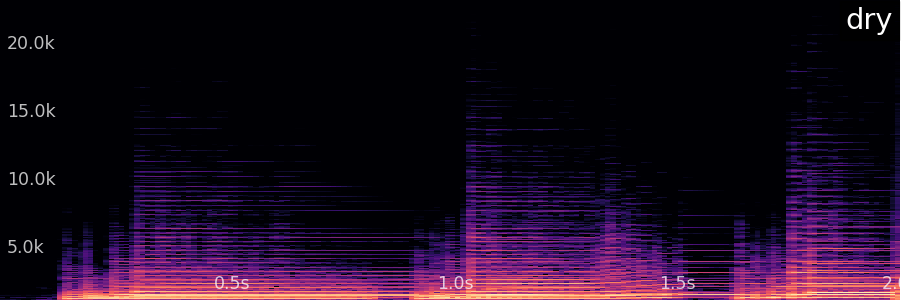
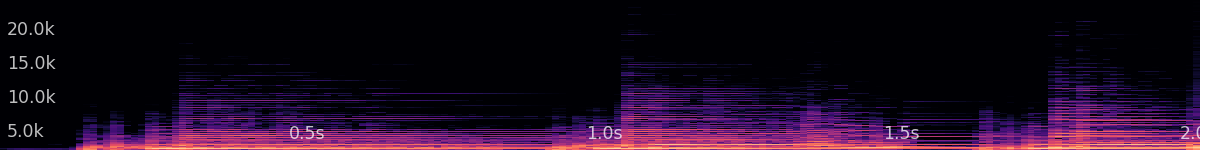

tensor([[ 1.1786, -1.3908, -1.7853,  ...,  0.4475,  0.1323,  0.5922]],
       device='cuda:0')


In [26]:
EQ_WORDS_ALL = ["warm", "cold", "soft", "loud", "happy", "bright", "soothing", "harsh", "heavy", "cool", "airy", "sharp", "muddy", "smooth"]
DRY_AUDIO = "/home/annie/research/text2fx/assets/guitar.wav"

model = get_model("ms_clap")

# --- compute embeddings for audealized signals ---
dry_sig = preprocess_audio(DRY_AUDIO).to(DEVICE)
dry_emb = model.get_audio_embeddings(dry_sig).detach()

dry_sig.cpu().widget("dry")
print(dry_emb)

warm



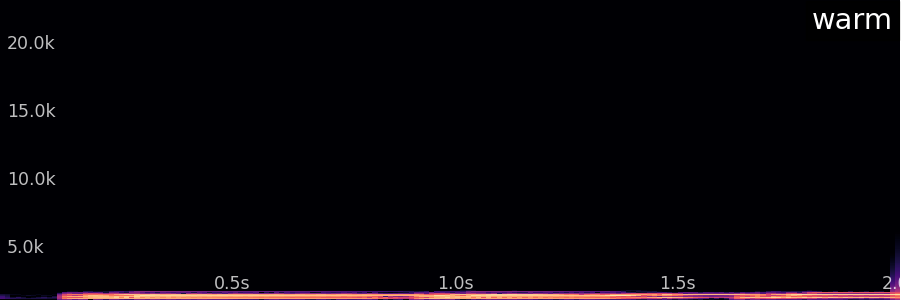
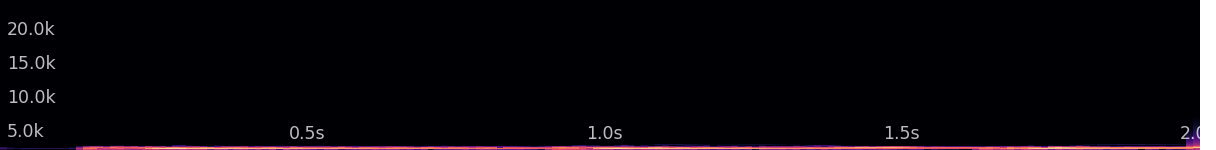

cold



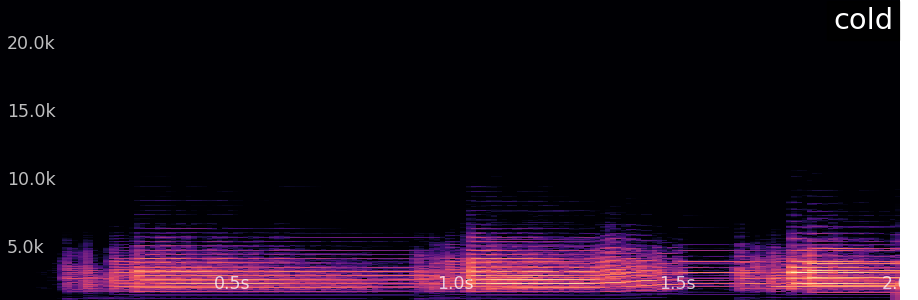
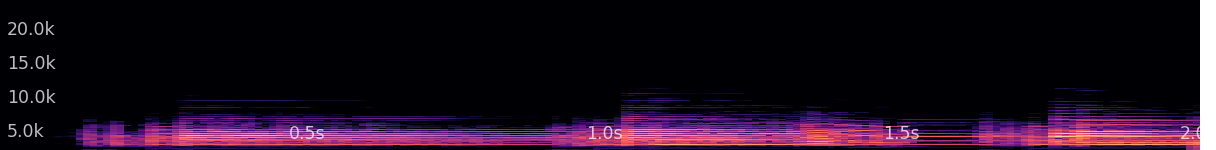

soft



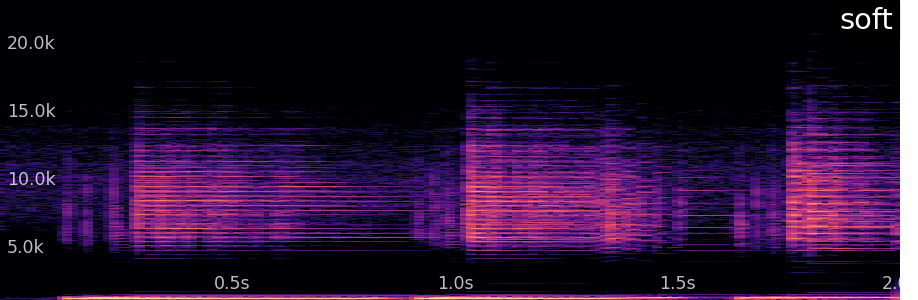
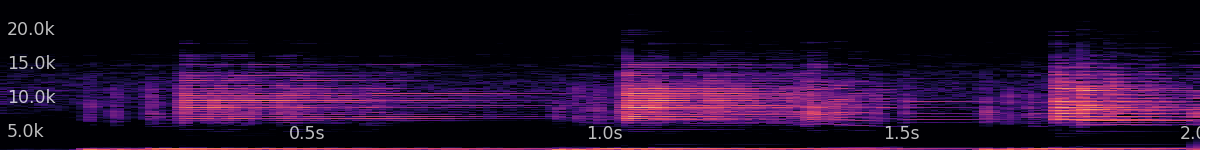

loud



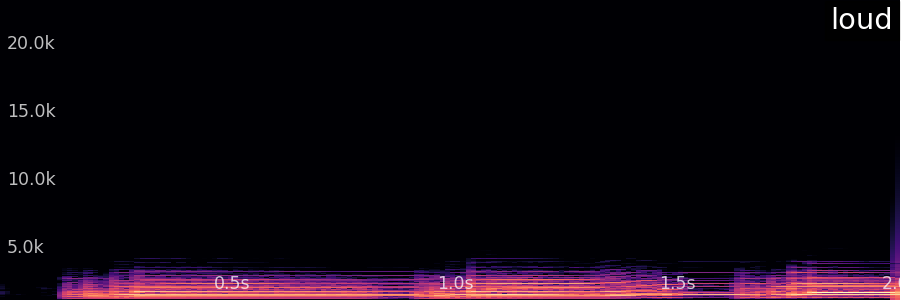
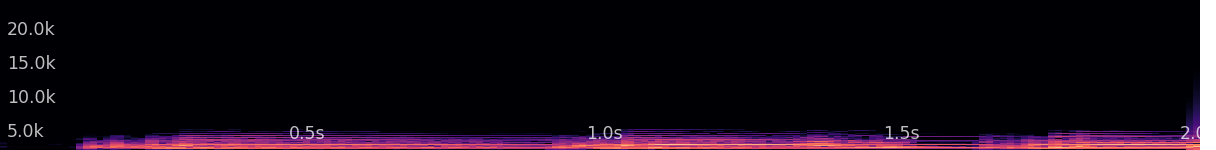

happy



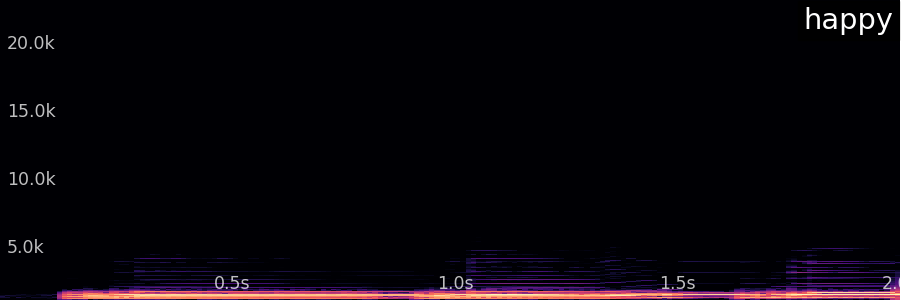
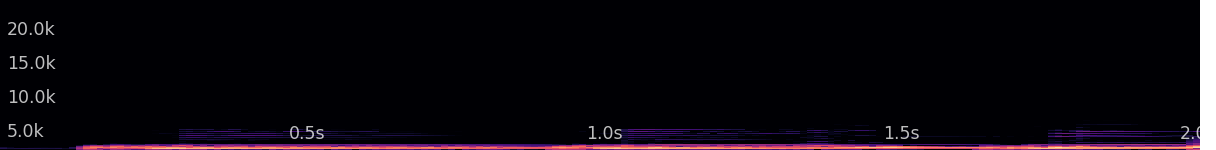

bright



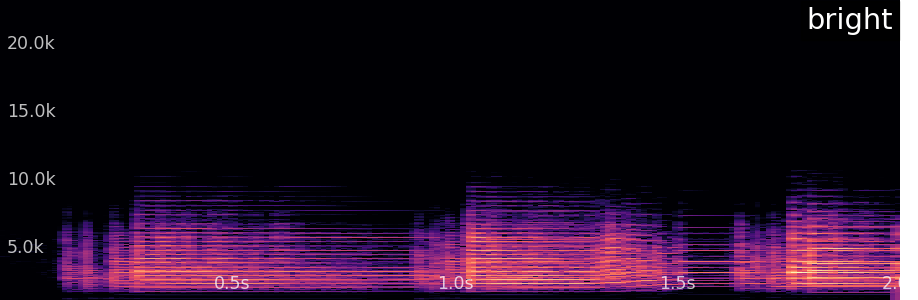
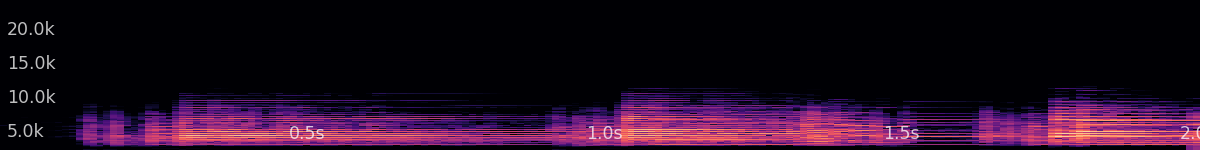

soothing



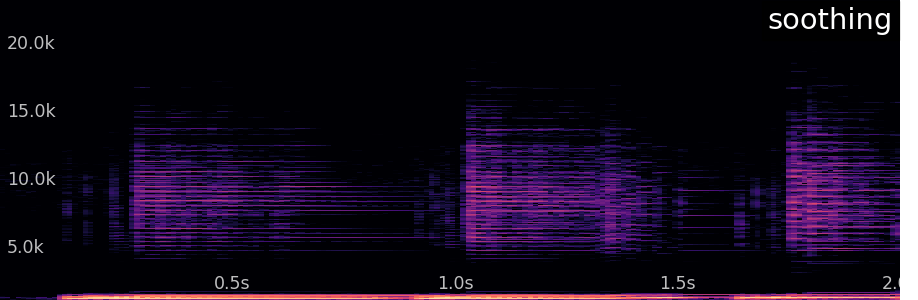
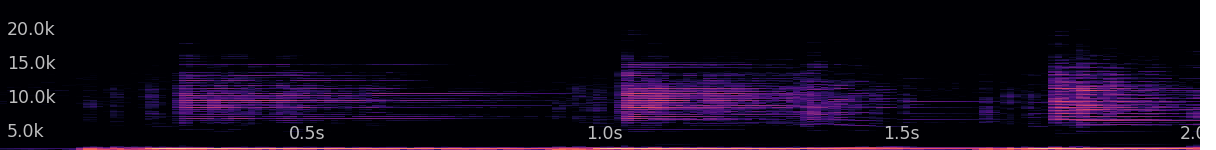

harsh



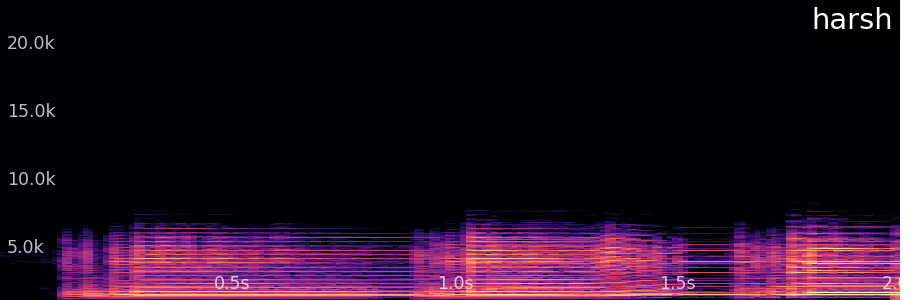
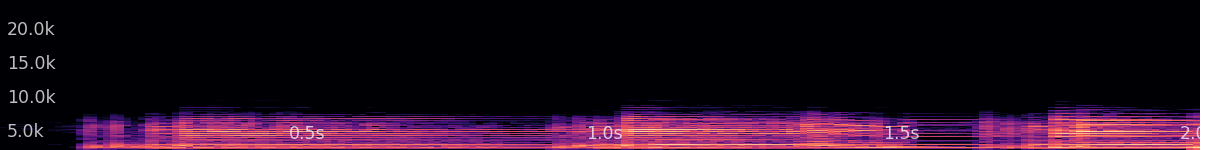

heavy



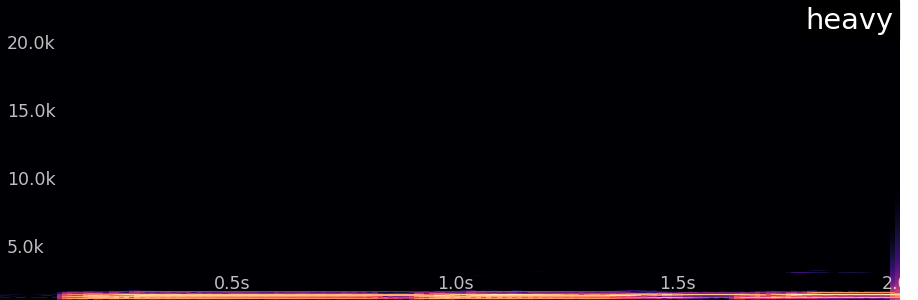
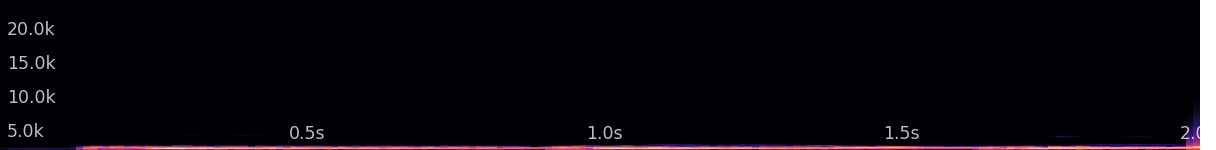

cool



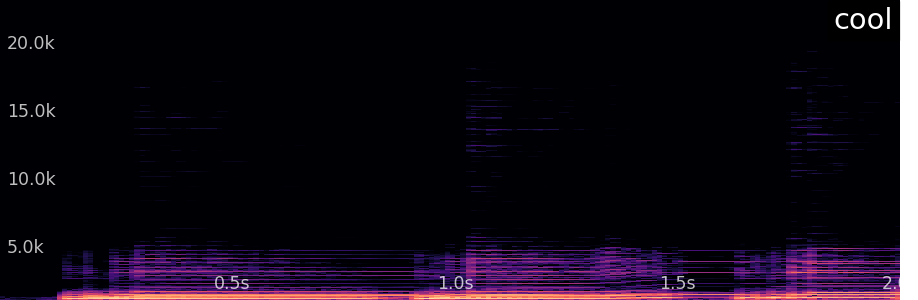
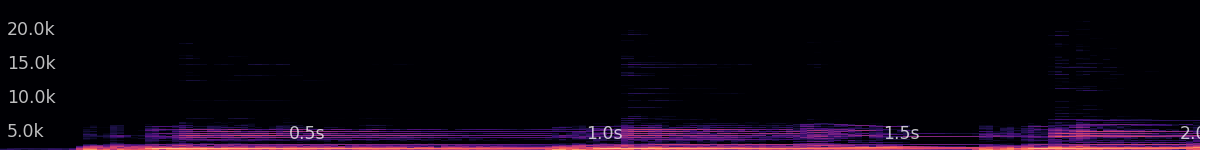

airy



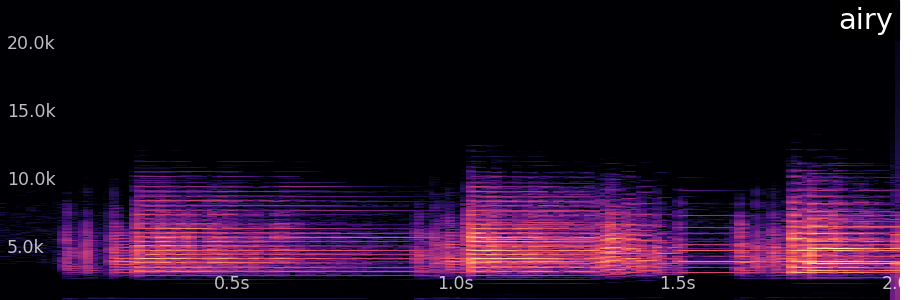
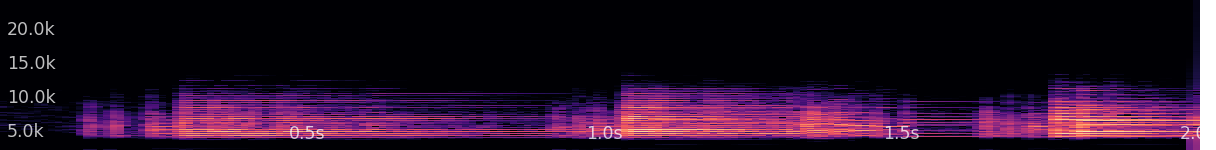

sharp



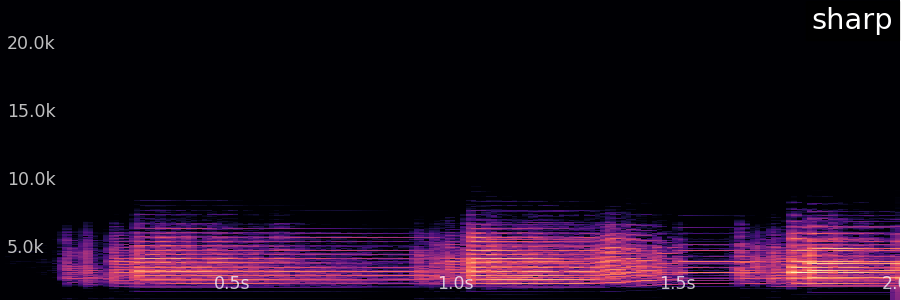
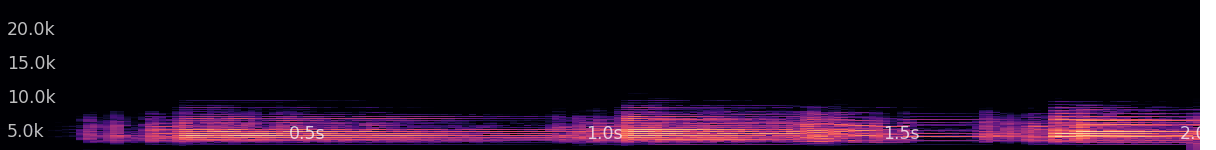

muddy



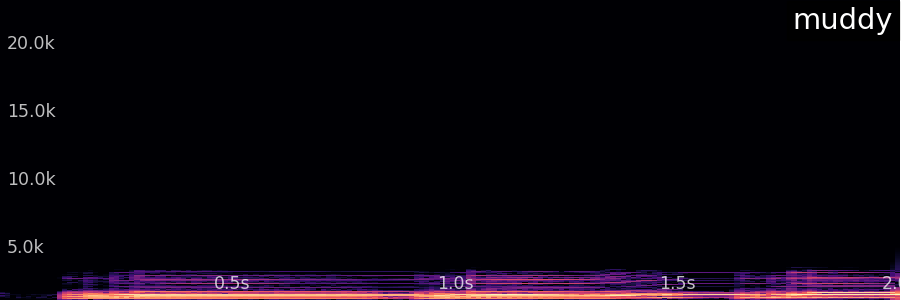
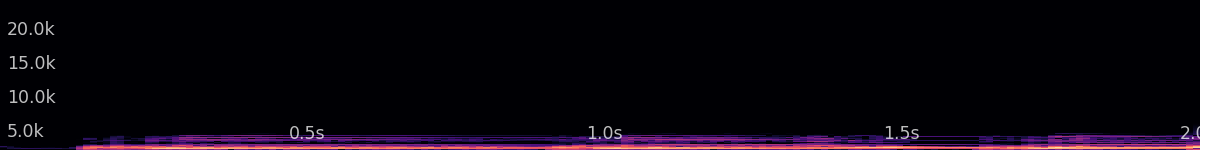

smooth



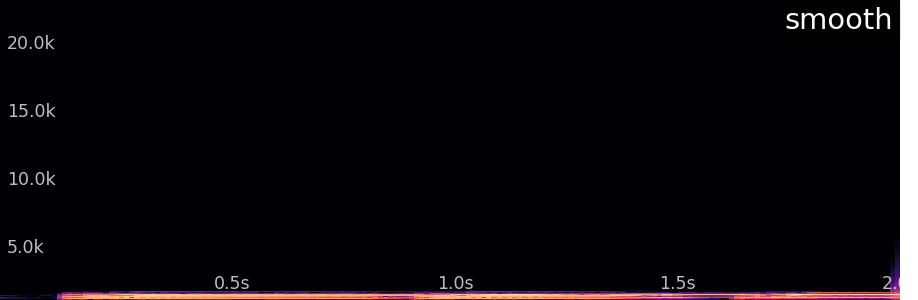
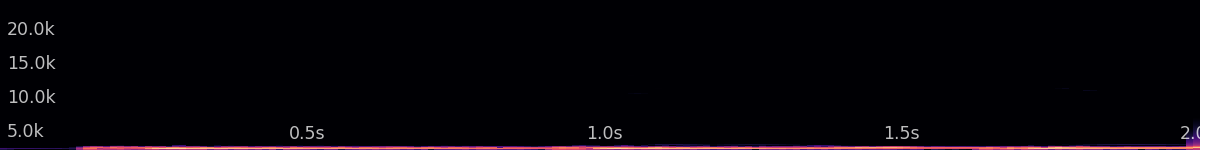

In [28]:


# --- setup ---

SAVE_DIR = "./"
embeddings = {}
for w in EQ_WORDS_ALL:
    print(f"{w}")
    wet_sig = apply_audealize_single_word(DRY_AUDIO, w, SAVE_DIR)
    wet_emb = model.get_audio_embeddings(wet_sig.to(DEVICE))
    wet_sig = preprocess_audio(wet_sig)
    wet_sig.cpu().widget(f"{w}")
    delta = torch.nn.functional.normalize(wet_emb - dry_emb, dim=-1)
    embeddings[w] = delta.cpu().detach().numpy().squeeze()


# --- compute pairwise distances in embedding space ---
words = list(embeddings.keys())
n = len(words)
dist_matrix = np.zeros((n, n))
for i, j in combinations(range(n), 2):
    dist = np.linalg.norm(embeddings[words[i]] - embeddings[words[j]])
    dist_matrix[i, j] = dist_matrix[j, i] = dist

# --- greedy selection for diversity ---
selected = [words[np.random.randint(n)]]
while len(selected) < 10:
    remaining = [w for w in words if w not in selected]
    avg_dist = {
        w: np.mean([dist_matrix[words.index(w), words.index(s)] for s in selected])
        for w in remaining
    }
    next_word = max(avg_dist, key=avg_dist.get)
    selected.append(next_word)

EQ_words_top_10 = selected
print("Top 10 perceptually distinct words:", EQ_words_top_10)


In [29]:

# ---------------------------------------------------------
# 4. Create 2D coordinates
# ---------------------------------------------------------
X = np.stack([embeddings[w] for w in EQ_words_top_10])
coords_2d = PCA(2).fit_transform(X)
coords_2d = (coords_2d - coords_2d.min(0)) / (coords_2d.max(0) - coords_2d.min(0))



Top 10 perceptually distinct words: ['cool', 'bright', 'warm', 'soft', 'cold', 'soothing', 'happy', 'airy', 'loud', 'smooth']


In [34]:
import numpy as np, torch
from itertools import combinations
from text2fx.sap_main import get_model 
from audiotools import AudioSignal

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
CLAP = get_model("ms_clap")  # or "laion_clap"

# Dry reference
DRY_AUDIO = "/home/annie/research/text2fx/assets/guitar.wav"
dry_sig = AudioSignal(DRY_AUDIO).to_mono().resample(44100).ensure_max_of_audio().to(DEVICE)
with torch.no_grad():
    dry_emb = torch.nn.functional.normalize(CLAP.get_audio_embeddings(dry_sig), dim=-1)  # (1,D)

# Choose the words you want to anchor with Audealize FX
EQ_WORDS_ALL = ["warm","cold","soft","loud","happy","bright","soothing","harsh","heavy","cool"]

# Build anchors: wet audio (via your audealize path) -> embedding delta
anchors = {}
for w in EQ_WORDS_ALL:
    wet_sig = apply_audealize_single_word(DRY_AUDIO, w, SAVE_DIR)  # returns AudioSignal
    wet_sig = wet_sig.to(DEVICE)
    with torch.no_grad():
        wet_emb = torch.nn.functional.normalize(CLAP.get_audio_embeddings(wet_sig), dim=-1)  # (1,D)
    delta = torch.nn.functional.normalize(wet_emb - dry_emb, dim=-1)  # (1,D)
    anchors[w] = {
        "delta": delta.squeeze(0).cpu().numpy(),  # store as np for convenience
        # optional: stash the wet signal for quick A/B
        "wet_sig": wet_sig.cpu()
    }
print(anchors)

{'warm': {'delta': array([-0.02140492,  0.01486446,  0.07765311, ...,  0.00190278,
        0.02509964, -0.0081279 ], dtype=float32), 'wet_sig': <audiotools.core.audio_signal.AudioSignal object at 0x7f3a6b06a070>}, 'cold': {'delta': array([-1.6318571e-02, -3.9128648e-05, -7.2194198e-03, ...,
        7.2108186e-03,  5.4067113e-03, -4.2258650e-02], dtype=float32), 'wet_sig': <audiotools.core.audio_signal.AudioSignal object at 0x7f3a6b06ab50>}, 'soft': {'delta': array([-0.01573615,  0.00268774,  0.05565143, ...,  0.00668918,
       -0.00267804,  0.04077605], dtype=float32), 'wet_sig': <audiotools.core.audio_signal.AudioSignal object at 0x7f3a6b06ac10>}, 'loud': {'delta': array([-0.02732524,  0.02509653,  0.05176946, ...,  0.02433404,
        0.0253508 , -0.03441477], dtype=float32), 'wet_sig': <audiotools.core.audio_signal.AudioSignal object at 0x7f3a6b06a610>}, 'happy': {'delta': array([-0.0398057 , -0.00751823,  0.05959647, ..., -0.00435657,
        0.03106301, -0.00305543], dtype=float3

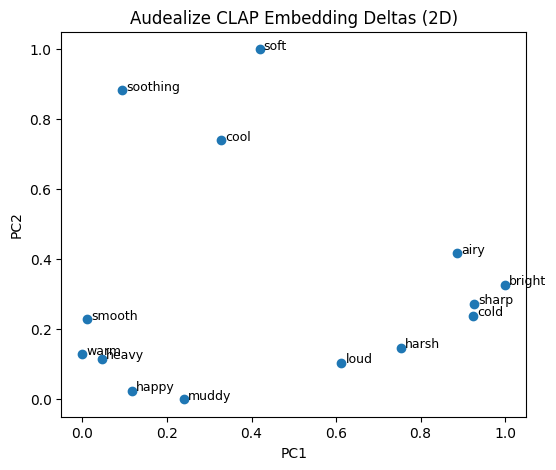

In [35]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

words = list(embeddings.keys())
A = np.stack([embeddings[w] for w in words])
coords_2d = PCA(2).fit_transform(A)
coords_2d = MinMaxScaler().fit_transform(coords_2d)  # scale to [0,1]

plt.figure(figsize=(6,5))
plt.scatter(coords_2d[:,0], coords_2d[:,1])
for i,w in enumerate(words):
    plt.text(coords_2d[i,0]+0.01, coords_2d[i,1], w, fontsize=9)
plt.title("Audealize CLAP Embedding Deltas (2D)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.show()


In [46]:
coords_2d

array([[0.        , 0.12781782],
       [0.9230736 , 0.23907144],
       [0.41893488, 1.0000001 ],
       [0.61254895, 0.10434452],
       [0.11720952, 0.02404621],
       [0.9999999 , 0.3274082 ],
       [0.09367085, 0.8830763 ],
       [0.75316143, 0.14776051],
       [0.04580581, 0.11547624],
       [0.32727888, 0.7402862 ],
       [0.8862891 , 0.41808966],
       [0.926579  , 0.2731009 ],
       [0.24060826, 0.        ],
       [0.01058793, 0.22822516]], dtype=float32)

In [41]:
from text2fx.sap_apply import main as t2fx
from text2fx.core import preprocess_audio

def interpolate_deltas(x, y, coords, deltas, sharpness=8.0):
    """Return blended CLAP delta for 2D position (x,y)."""
    xy = np.array([x, y])
    d = np.linalg.norm(coords - xy[None, :], axis=1) + 1e-6
    w = np.exp(-sharpness * d)
    w /= w.sum()
    blended = (w[:, None] * deltas).sum(axis=0)
    blended /= np.linalg.norm(blended) + 1e-9
    return torch.from_numpy(blended).float().unsqueeze(0).to(DEVICE)
# pick an arbitrary location in the semantic map
x, y = 0.4, 0.7

# build custom target embedding
deltas = np.stack([embeddings[w] for w in words])
custom_target = torch.nn.functional.normalize(
    torch.from_numpy(dry_emb.cpu().numpy() + interpolate_deltas(x, y, coords_2d, deltas)[0].cpu().numpy()),
    dim=-1
).to(DEVICE)

# run optimization (short run just to test)
out_sig, out_params, out_dict = t2fx(
    audio_path=DRY_AUDIO,
    fx_chain=["eq"],
    text_target=["_"],
    custom_embedding_target=custom_target
)


text2fx on full sig
2. created channel from ['eq'] ... [<dasp_pytorch.modules.ParametricEQ object at 0x7f3a6ab35820>]
Using custom embedding target for optimization...
Criterion: cosine-sim
[Seed set to 0] (deterministic=False)
Using provided custom embedding target...
Starting optimization with 1 samples...
pls_normalize: True


step: 600/600, loss

Direcitonal vector from source:
Initial loss: [0.52382976] // Final loss: [0.17558753]
Change in loss from iteration 0 to 599: [-0.34824222]



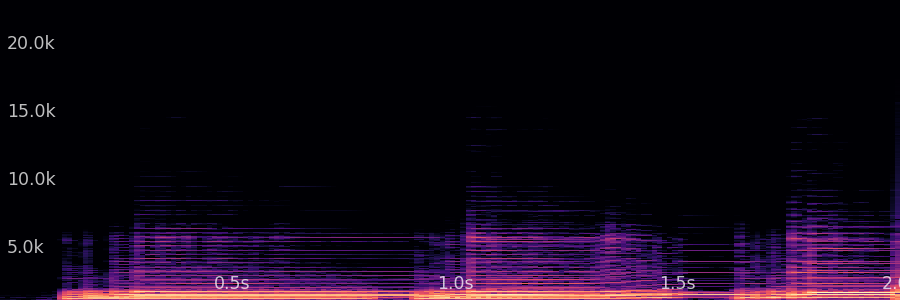
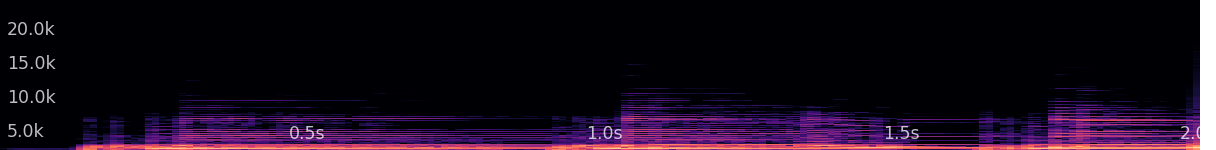

In [42]:
out_sig.widget()

In [47]:
# pick an arbitrary location in the semantic map
x, y = 1.0, 0.3274082

# build custom target embedding
deltas = np.stack([embeddings[w] for w in words])
custom_target = torch.nn.functional.normalize(
    torch.from_numpy(dry_emb.cpu().numpy() + interpolate_deltas(x, y, coords_2d, deltas)[0].cpu().numpy()),
    dim=-1
).to(DEVICE)

# run optimization (short run just to test)
out_sig, out_params, out_dict = t2fx(
    audio_path=DRY_AUDIO,
    fx_chain=["eq"],
    text_target=["_"],
    custom_embedding_target=custom_target
)

text2fx on full sig
2. created channel from ['eq'] ... [<dasp_pytorch.modules.ParametricEQ object at 0x7f3a6aa8a4c0>]
Using custom embedding target for optimization...
Criterion: cosine-sim
[Seed set to 0] (deterministic=False)
Using provided custom embedding target...
Starting optimization with 1 samples...
pls_normalize: True


step: 600/600, loss


Direcitonal vector from source:
Initial loss: [0.55918646] // Final loss: [0.14129615]
Change in loss from iteration 0 to 599: [-0.4178903]



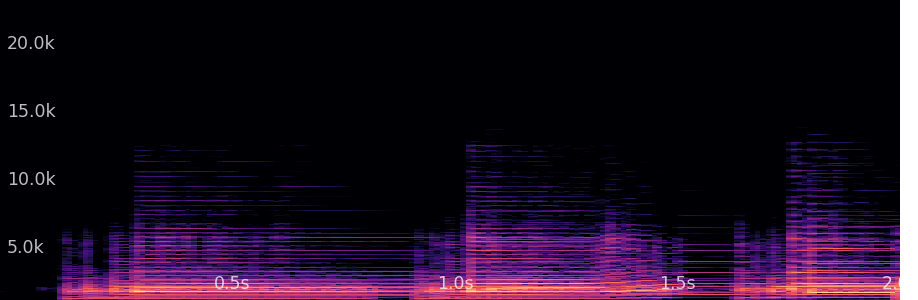
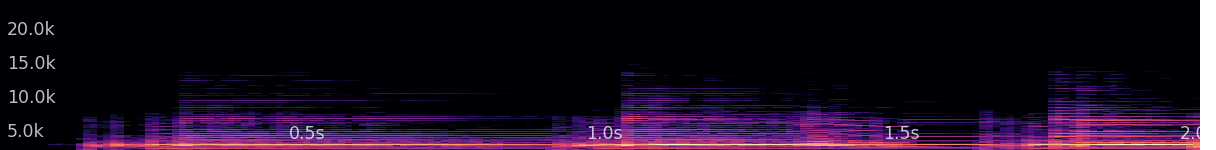

In [49]:
out_sig.widget()

In [50]:
# pick an arbitrary location in the semantic map
x, y = 0.5, 0.3274082

# build custom target embedding
deltas = np.stack([embeddings[w] for w in words])
custom_target = torch.nn.functional.normalize(
    torch.from_numpy(dry_emb.cpu().numpy() + interpolate_deltas(x, y, coords_2d, deltas)[0].cpu().numpy()),
    dim=-1
).to(DEVICE)

    
# run optimization (short run just to test)
out_sig, out_params, out_dict = t2fx(
    audio_path=DRY_AUDIO,
    fx_chain=["eq"],
    text_target=["_"],
    custom_embedding_target=custom_target
)

text2fx on full sig
2. created channel from ['eq'] ... [<dasp_pytorch.modules.ParametricEQ object at 0x7f3a719b6f10>]
Using custom embedding target for optimization...
Criterion: cosine-sim
[Seed set to 0] (deterministic=False)
Using provided custom embedding target...
Starting optimization with 1 samples...
pls_normalize: True


step: 600/600, loss: 0.188: 100%|██████████████████████████████████████| 600/600 [00:42<00:00, 14.19it/s]

Direcitonal vector from source:
Initial loss: [0.42303854] // Final loss: [0.16630365]
Change in loss from iteration 0 to 599: [-0.2567349]



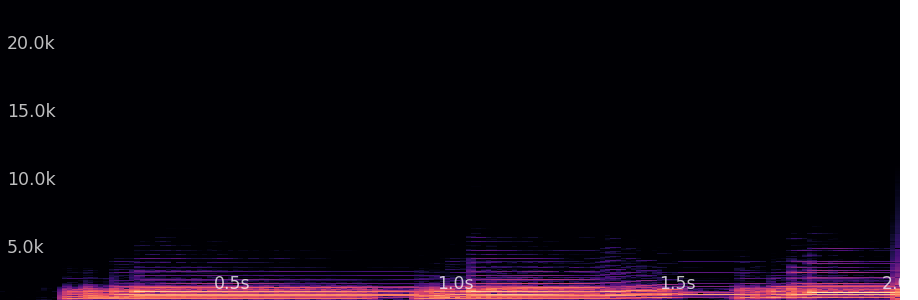
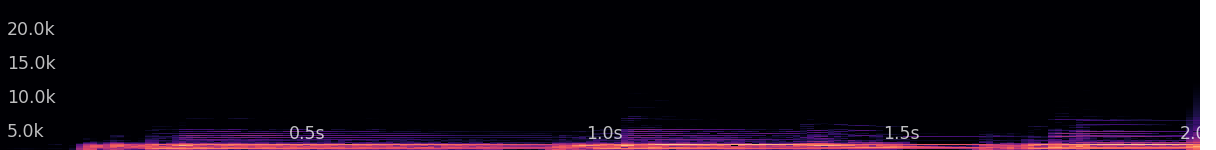

In [53]:
out_sig.widget()